**Denetimsiz Öğrenme ve Boyut İndirgeme Metodolojisi**

Denetimsiz öğrenme, veri setinde hedef etiketlerin (y) bulunmadığı durumlarda verinin yapısal özelliklerini ve gizil örüntülerini keşfetmek için kullanılır. Bu kapsamda Temel Bileşenler Analizi (Principal Component Analysis - PCA), verideki varyansı maksimum düzeyde koruyarak boyut sayısını azaltan lineer bir tekniktir.

**1. Model Yapılandırması ve Boyut İndirgeme**

Yüksek boyutlu bir veri setini (örneğin 4 boyutlu Iris verisi) daha düşük bir boyuta (2B) indirgemek, verinin görselleştirilmesini ve karmaşıklığının azaltılmasını sağlar.

In [ ]:
import pandas as pd

iris = pd.read_csv('iris_dataset.csv')
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
from sklearn.decomposition import PCA

# 1. Modelin örneklendirilmesi (2 bileşen hedefliyoruz)
model_pca = PCA(n_components=2)

# Define X_iris from the loaded iris DataFrame by dropping 'target' and 'species' columns

X_iris = iris.drop(['target', 'species'], axis=1)

# 2. Verinin modele uyumlandırılması ve dönüştürülmesi
# Denetimsiz öğrenme olduğu için sadece X_iris kullanılır.
X_2D = model_pca.fit_transform(X_iris)


`X_iris` =: Yapılan işlemin sonucunu X_iris isimli yeni bir değişkene kaydeder.

`iris`: Üzerinde işlem yapılan orijinal veri setini (DataFrame) ifade eder.

`.drop()`: Pandas kütüphanesinde veri çerçevesinden satır veya sütunları silmek/çıkarmak için kullanılan fonksiyondur.

['target', 'species']: Veriden çıkarılmak istenen sütunların isimlerini belirten listedir.

`axis=1`: Silme işleminin yatayda (satırlara - axis=0) değil, dikeyde (sütunlara - axis=1) uygulanacağını belirtir.

In [ ]:
model_pca.fit(X_iris)

PCA(n_components=2)


`model_pca`: Daha önceden tanımlanmış olan PCA modelini (örneğin `model_pca = PCA(n_components=2)`) temsil eden değişkendir.

`.fit()`: Scikit-learn kütüphanesinde, bir denetimsiz öğrenme veya boyut indirgeme modelinin veriden istatistiksel özellikleri öğrenmesini sağlayan metottur.


Makine öğrenmesinde PCA, yüksek boyutlu verileri bilgi kaybını en aza indirerek daha az boyuta indirmek için kullanılan bir boyut indirgeme (dimensionality reduction) yöntemidir.

`model_pca.fit(X_iris)` komutu çalıştırıldığında model şu işlemleri gerçekleştirir:

Verinin yapısını inceler: Değişkenler arasındaki varyansı ve ilişkileri analiz eder.

Temel bileşenleri (Principal Components) hesaplar: Verinin varyansını en iyi açıklayan yeni ve dik eksenleri (bileşenleri) bulur.

Modeli hazırlar: Bu aşama modelin "öğrenme" (fit) aşamasıdır.

Önemli Not: Sadece `fit()` metodu kullanıldığında model veriden öğrenir ancak verinin kendisini dönüştürmez. Veriyi boyutları indirgenmiş yeni biçimde kullanmak için genellikle `model_pca.transform(X_iris)` veya ikisini bir arada yapan `model_pca.fit_transform(X_iris)` kullanılır.

**2. Veri Entegrasyonu ve Görsel Analiz**

İndirgenmiş özniteliklerin orijinal veri setiyle birleştirilmesi, sınıflar arası ayrılabilirliğin görsel olarak doğrulanmasına olanak tanır.

In [ ]:
# Sonuçların ana veri setine yeni öznitelikler (PCA1, PCA2) olarak eklenmesi
iris['PCA1'] = X_2D[:, 0]
iris['PCA2'] = X_2D[:, 1]

# İlk 5 satırın yapısal kontrolü
print(iris.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species      PCA1      PCA2  
0       0  setosa -2.684126  0.319397  
1       0  setosa -2.714142 -0.177001  
2       0  setosa -2.888991 -0.144949  
3       0  setosa -2.745343 -0.318299  
4       0  setosa -2.728717  0.326755  


Görselleştirme aşamasında seaborn kütüphanesinin sağladığı araçlar, modelin başarısını nitel olarak değerlendirmemizi sağlar:

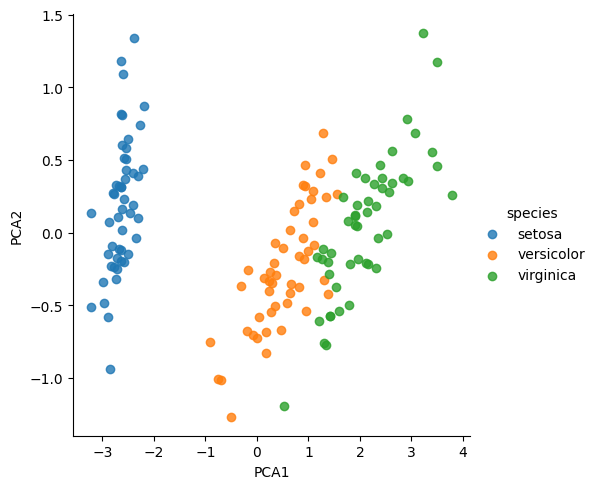

In [ ]:
import seaborn as sns

# PCA sonuçlarının türlere göre renklendirilerek görselleştirilmesi
sns.lmplot(x="PCA1", y="PCA2", hue='species', data=iris, fit_reg=False)

`sns.lmplot(x="PCA1", y="PCA2", hue='species', data=iris, fit_reg=False)`
Bu kod satırı, seaborn (kısaca sns) veri görselleştirme kütüphanesini kullanarak iki boyutlu bir dağılım grafiği (scatterplot) çizmek için kullanılır. Temel olarak, veri noktalarını iki ana bileşen ekseninde görselleştirmeyi ve grupları renklerine göre birbirinden ayırmayı sağlar.

Aşağıda fonksiyonun içerdiği parametrelerin ayrıntılı açıklaması yer almaktadır:

`x="PCA1"`: Grafiğin X ekseninde, temel bileşen analizi (PCA) sonucu elde edilen birinci bileşenin (PCA1) değerlerinin yer alacağını belirtir.

`y="PCA2"`: Grafiğin Y ekseninde, temel bileşen analizi sonucu elde edilen ikinci bileşenin (PCA2) değerlerinin yer alacağını belirtir.

`hue='species'`: Veri noktalarını species (tür) sütunundaki değerlere göre farklı renklerle gruplandırır. Bu sayede farklı bitki türlerinin PCA uzayında nerede kümelendiğini görebilirsiniz.

`data=iris`: Çizimde kullanılacak olan veri çerçevesini (DataFrame) belirtir.

f`it_reg=False`: Grafiğe herhangi bir doğrusal regresyon (eğilim) çizgisi çizilmemesini sağlar.

 `lmplot` normalde verilerin üzerine bir çizgi çizer, bu parametre ile bu özellik kapatılmıştır.

**3. Akademik Değerlendirme**

PCA algoritması, tür etiketlerini (labels) girdi olarak kullanmamasına rağmen, öznitelik uzayındaki varyansı analiz ederek sınıfları birbirinden belirgin şekilde ayrıştırmayı başarmıştır. Bu durum, veri setindeki özniteliklerin (yaprak ölçümleri) çiçek türlerini tanımlamada yüksek bir ayırt edici güce sahip olduğunu bilimsel olarak kanıtlar.

**Denetimsiz Öğrenme: Kümeleme Analizi ve GMM (Gaussian Mixture Model) Metodolojisi**
Kümeleme, veri kümesindeki örneklerin herhangi bir öncül etiket (label) bilgisi olmaksızın, öznitelik uzayındaki benzerliklerine göre homojen alt gruplara ayrılması sürecidir. Bu kapsamda kullanılan Gaussian Mixture Models (GMM), verinin birden fazla normal dağılımın bileşiminden oluştuğunu varsayan olasılıksal bir modeldir.

**1. Modelin Yapılandırılması ve Eğitimi**

GMM algoritması, verideki gizil (latent) grupları saptamak için kullanılır. Model kurulurken en kritik hiperparametre, hedeflenen grup sayısını belirten n_components argümanıdır.

In [ ]:
from sklearn.mixture import GaussianMixture

# 1. Model sınıfının örneklendirilmesi ve hiperparametre tanımlama
# 'covariance_type' parametresi kümelerin geometrik esnekliğini belirler.
model_gmm = GaussianMixture(n_components=3, covariance_type='full')

# 2. Modelin veriye uyumlandırılması (Fitting)
# ÖNEMLİ: Denetimsiz öğrenmede hedef değişken (y_iris) kullanılmaz.
model_gmm.fit(X_iris)

# 3. Kümeleme etiketlerinin öngörülmesi
y_gmm = model_gmm.predict(X_iris)

`model_gmm` =: Oluşturulan modeli hafızada tutmak için kullanılan değişkendir.

`GaussianMixture(...)`: Scikit-learn kütüphanesinin mixture modülünde yer alan ve veri noktalarının belirli sayıda Gauss dağılımının birleşimiyle oluştuğunu varsayan algoritmadır.

`n_components=3`: Veri setinde bulunması beklenen küme (veya bileşen) sayısını belirtir. Burada verinin 3 farklı gruba ayrılacağı tanımlanmıştır.

`covariance_type=`'full': Her bir bileşenin (kümenin) kendi genel (full) kovaryans matrisine sahip olacağını belirtir. Bu, kümelerin farklı yönlerde ve boyutlarda eliptik şekiller almasına olanak tanır.

`model_gmm.fit(X_iris)` komutu çalıştırıldığında model, Beklenti-Maksimizasyon (Expectation-Maximization - EM) algoritmasını kullanarak arka planda şu adımları gerçekleştirir:

Parametre Tahmini: Veri noktalarının oluşturduğu 3 farklı kümenin merkezlerini (ortalama/mean) ve şekillerini (kovaryans) hesaplar.

Dağılımları Öğrenir: Her bir veri noktasının hangi kümeden gelmiş olabileceğine dair olasılık yoğunluk fonksiyonlarını çıkarır.

Veriye Uyum Sağlama: Modeli, girdi olarak verdiğiniz X_iris verisinin istatistiksel dağılımına en uygun hale getirir.

`y_gmm = model_gmm.predict(X_iris)` satırı, daha önce eğitilmiş olan Gaussian Mixture Model (GMM - Gauss Karışım Modeli) kullanılarak, veri setindeki her bir veri noktasının (gözlemin) hangi kümeye ait olduğunun tahmin edilmesini ve bu tahminlerin bir değişkene atanmasını sağlar.


`y_gmm` =: Modelin tahmin ettiği küme etiketlerinin (örneğin 0, 1 veya 2) kaydedileceği yeni değişkendir.

`.predict()`: Scikit-learn kütüphanesinde, eğitilmiş bir modelin yeni veya mevcut veriler üzerinde tahmin/atama yapmasını sağlayan fonksiyondur.

`X_iris`: Kümeleme işleminin yapılacağı, hedef değişkenlerin çıkarıldığı özellikler matrisidir.

**2. Veri Entegrasyonu ve Görsel Doğrulama**

Algoritma tarafından atanan küme etiketleri, analiz edilebilirliği artırmak amacıyla ana veri setine yeni bir öznitelik olarak dahil edilir.

In [ ]:
# Kümeleme sonuçlarının veri setine eklenmesi
iris['kumeleme'] = y_gmm

# Yapısal kontrol (İlk 5 örneklem)
print(iris.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species      PCA1      PCA2  kumeleme  
0       0  setosa -2.684126  0.319397         0  
1       0  setosa -2.714142 -0.177001         0  
2       0  setosa -2.888991 -0.144949         0  
3       0  setosa -2.745343 -0.318299         0  
4       0  setosa -2.728717  0.326755         0  


Görselleştirme aşamasında, daha önce boyut indirgemesi yapılmış olan PCA bileşenleri üzerinden kümeleme başarısı analiz edilir:

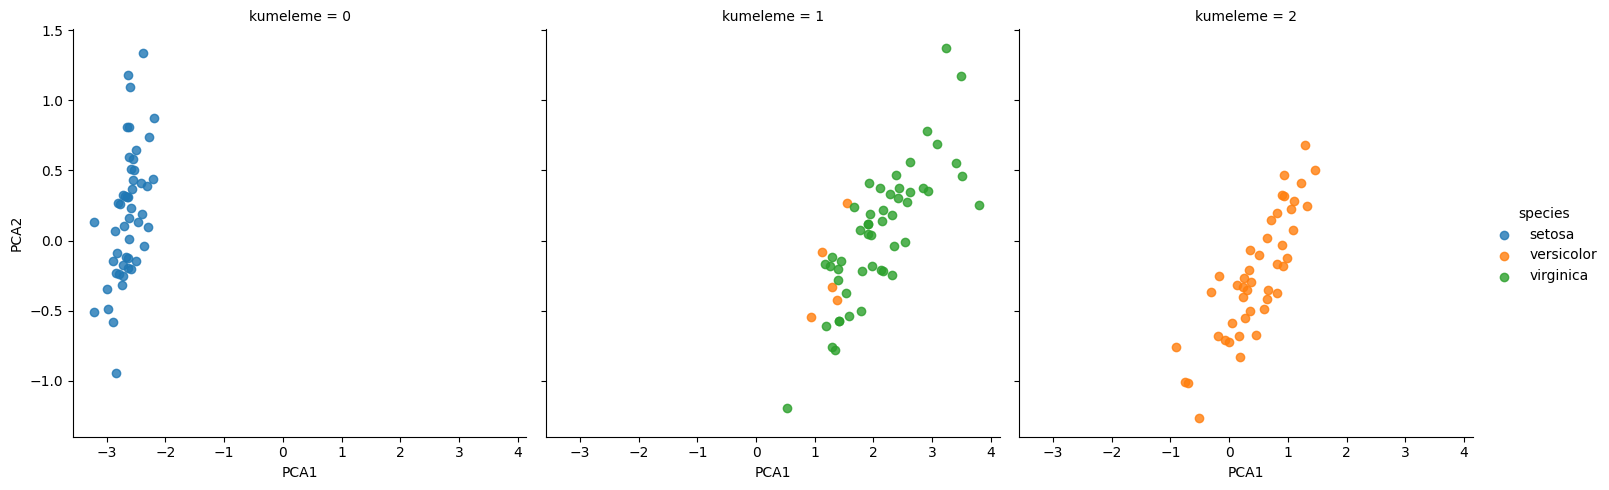

In [ ]:
import seaborn as sns

# Kümeleme sonuçlarının türlerden bağımsız olarak görselleştirilmesi
sns.lmplot(x="PCA1", y="PCA2", data=iris, hue='species',
           col='kumeleme', fit_reg=False)

**3. Akademik Değerlendirme ve Çıkarım**

Oluşturulan grafikler incelendiğinde, GMM algoritmasının herhangi bir uzman denetimi (etiket bilgisi) olmaksızın Setosa türünü diğerlerinden tamamen izole edebildiği gözlemlenmektedir. Diğer iki tür (Versicolor ve Virginica) arasındaki kısmi örtüşme, bu türlerin öznitelik uzayındaki varyans benzerliğinden kaynaklanan doğal bir sonuçtur.

**Sonuç:** Bu uygulama, makine öğrenmesi algoritmalarının verideki doğal hiyerarşiyi ve gruplanma eğilimlerini keşfetme yeteneğini kanıtlamaktadır. Bu tür yaklaşımlar, özellikle etiketlenmemiş büyük veri kümelerinde sınıf yapılarının ön keşfi için bilimsel bir temel sunar.

**Yüksek Boyutlu Verilerde Denetimli ve Denetimsiz Öğrenme: El Yazısı Rakam Tanıma**
El yazısı rakam tanıma süreci, her bir pikselin ayrı bir öznitelik (feature) olarak kabul edildiği yüksek boyutlu bir veri uzayında çalışmayı gerektirir. Bu çalışmada Digits veri seti üzerinden boyutsal indirgeme ve sınıflandırma analizi gerçekleştirilmiştir.

**1. Veri Temsili ve Ön İzleme**

Digits veri seti, 1797 adet 8×8 piksellik görüntüden oluşur. Her bir görüntü, 64 farklı piksel değerine sahip bir matris olarak temsil edilir.

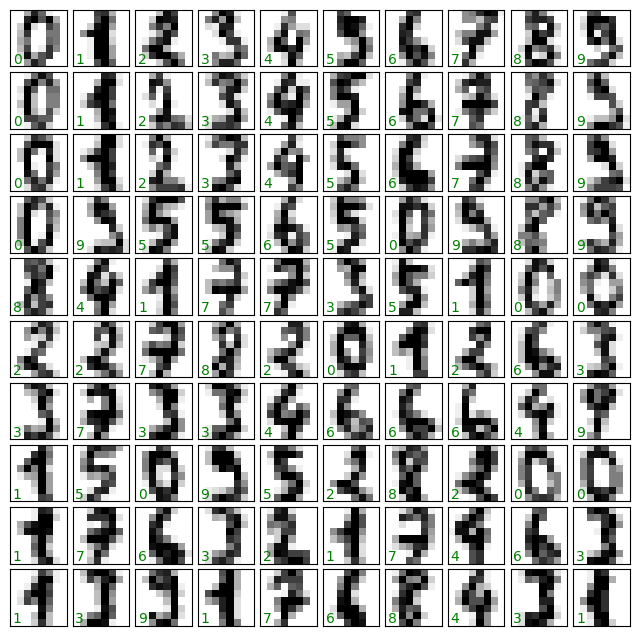

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# 1. Veri setinin yüklenmesi
digits = load_digits()

# 2. Görselleştirme: İlk 100 rakamın 10x10 matris formunda gösterimi
fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green')

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()
X=digits.data
y=digits.target
print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


In [ ]:
from sklearn.manifold import Isomap
iso=Isomap(n_components=2)
iso.fit(X)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Isomap()

In [ ]:
data2=iso.transform(X)
data2.shape

(1797, 2)

**2. Manifold Öğrenme ile Boyut İndirgeme (Isomap)**

64 boyutlu öznitelik uzayını görselleştirmek ve sınıfların ayrılabilirliğini sezgisel olarak anlamak için Isomap (Isometric Mapping) algoritması kullanılır. Bu yöntem, verinin topolojik yapısını koruyarak boyutu 2'ye indirger.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


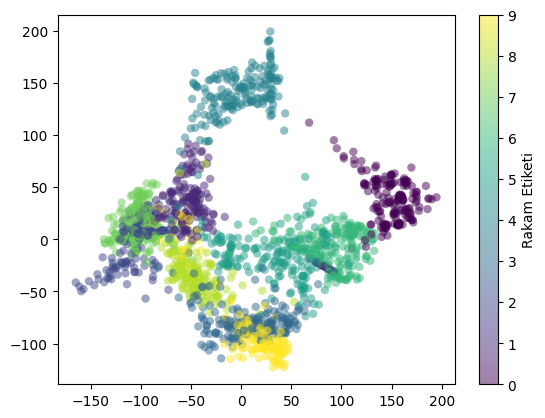

In [ ]:
from sklearn.manifold import Isomap

# 1. 64 boyuttan 2 boyuta indirgeme işlemi
iso = Isomap(n_components=2)
data_projected = iso.fit_transform(digits.data)

# 2. İndirgenmiş verinin saçılım grafiği (Scatter Plot)
plt.scatter(data_projected[:, 0], data_projected[:, 1], c=digits.target,
            edgecolors='none', alpha=0.5, cmap='viridis')
plt.colorbar(label='Rakam Etiketi', ticks=range(10))

**Akademik Gözlem:** Grafik incelendiğinde, rakamların öznitelik uzayında belirgin öbekler (clusters) oluşturduğu görülmektedir. Örneğin, 0 ve 1 rakamlarının yapısal farklılıkları nedeniyle uzayda tamamen ayrı konumlarda yer alması, basit bir sınıflandırma algoritmasının bu veride yüksek başarı göstereceğinin bilimsel kanıtıdır.

**3. Sınıflandırma ve Performans Analizi**

Modelin genelleme başarısını ölçmek amacıyla veri seti eğitim ve test olarak ayrıştırılmış, ardından **Gaussian Naive Bayes (GNB)** algoritması ile sınıflandırma yapılmıştır.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# 1. Veri Bölümleme (Train-Test Split)
Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target, random_state=0)

# 2. Model Eğitimi ve Tahmin
model = GaussianNB()
model.fit(Xtrain, ytrain)
y_model = model.predict(Xtest)

# 3. Doğruluk (Accuracy) Skoru
print(f"Model Doğruluk Oranı: {accuracy_score(ytest, y_model):.2f}")

Model Doğruluk Oranı: 0.83


**4. Hata Analizi: Karmaşıklık Matrisi (Confusion Matrix)**

Yalnızca doğruluk skoruna bakmak, modelin spesifik olarak hangi sınıfları birbiriyle karıştırdığını (misclassification) anlamak için yeterli değildir. Hata Matrisi, modelin tahmin performansını sınıf bazında detaylandırır.

Text(113.9222222222222, 0.5, 'Gerçek Değer')

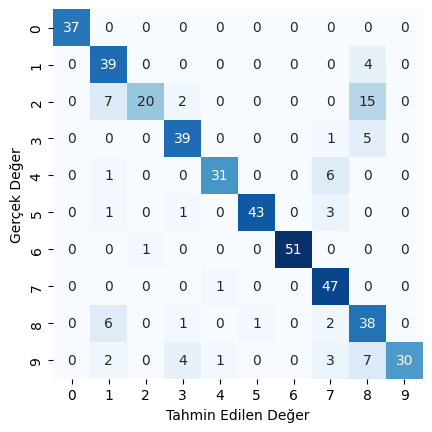

In [ ]:
# Hata Matrisinin oluşturulması ve Isı Haritası (Heatmap) ile görselleştirilmesi
mat = confusion_matrix(ytest, y_model)

sns.heatmap(mat, annot=True, square=True, cbar=False, cmap='Blues')
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Gerçek Değer')

**Sonuç ve Değerlendirme:**

Yapılan analiz sonucunda modelin yaklaşık %83 oranında bir doğruluk skoruna ulaştığı saptanmıştır. Hata matrisi incelendiğinde, özellikle görsel benzerlikleri yüksek olan rakamlar (örneğin 1, 4 ve 8) arasındaki karışıklıklar net bir şekilde gözlemlenebilmektedir. Bu durum, modelin iyileştirilmesi için hangi özelliklere odaklanılması gerektiğine dair analitik bir veri sunar.